# NB06 — Fusão Multimodal e Priority Queue

## Objetivo
Combinar as três probabilidades produzidas pelos baselines unimodais (`proba_tab`, `proba_text`, `proba_img`) num modelo único de fusão. Avaliar no test set (intocado até este ponto) e produzir uma fila de prioridade rankeada com tiers operacionais.

## Inputs
- `val_predictions.parquet` e `test_predictions.parquet` dos NB03, NB04 e NB05
- `data/processed/splits_index.parquet`
- `data/processed/X_val_tab.parquet`, `X_test_tab.parquet` (apenas para o experimento refutado da fusão enriquecida)

## Outputs
- `results/nb06_multimodal/model_A_fusion_probas.joblib`: modelo oficial
- `results/nb06_multimodal/model_B3_refuted.joblib`: experimento refutado (preservado para auditoria)
- `results/nb06_multimodal/val_predictions.parquet`, `test_predictions.parquet`
- `results/nb06_multimodal/priority_queue.parquet` + `.csv`: fila rankeada do test set
- `results/nb06_multimodal/tier_config.json`:  cutoffs e racional dos tiers
- `results/nb06_multimodal/metrics.json`: métricas finais
- `results/nb06_multimodal/final_comparison.csv`: tabela comparativa dos baselines + multimodal

## Decisões metodológicas
- **Fusão pura (Modelo A) supera fusão enriquecida**: testámos três variantes (B/B2/B3) com features tabulares brutas; todas sofreram overfit persistente mesmo com `alpha=1.0` (100× o default)
- **Pivot para ranking:** Modelo A produz `P(slow)` em gama estreita [0.43, 0.53] → otimização de threshold binário é degenerada → solução é tratar o output como score de ranking
- **Tiers operacionais** (High 20% / Medium 30% / Low 50%) alinhados com capacidade realista de intervenção do abrigo
- **Diagnóstico de Sterilized:** paradoxo de Simpson identificado e documentado (corr marginal vs efeito condicional à idade)

In [ ]:
# =============================================================================
# NB06 — Multimodal Fusion
# Objetivo: combinar predictions dos ramos tabular (NB03), texto (NB04) e
# imagem (NB05) num classificador único, testando duas estratégias de fusão.
# =============================================================================

# --- Standard library ---
import json
import warnings
from pathlib import Path

# --- Scientific stack ---
import numpy as np
import pandas as pd

# --- Modelling ---
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

# --- Persistence ---
import joblib

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Config ---
warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Paths ---
PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> raiz
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
CACHE_DIR = DATA_DIR / "cache"
RESULTS_DIR = PROJECT_ROOT / "results"

NB03_DIR = RESULTS_DIR / "nb03_baseline_tabular"
NB04_DIR = RESULTS_DIR / "nb04_baseline_texto"
NB05_DIR = RESULTS_DIR / "nb05_baseline_imagem"
NB06_DIR = RESULTS_DIR / "nb06_multimodal"
NB06_DIR.mkdir(parents=True, exist_ok=True)

# --- Sanity check ---
print("Paths configurados:")
print(f"  PROCESSED_DIR existe: {PROCESSED_DIR.exists()}")
print(f"  NB03_DIR existe:      {NB03_DIR.exists()}")
print(f"  NB04_DIR existe:      {NB04_DIR.exists()}")
print(f"  NB05_DIR existe:      {NB05_DIR.exists()}")
print(f"  NB06_DIR criado em:   {NB06_DIR}")

Paths configurados:
  PROCESSED_DIR existe: True
  NB03_DIR existe:      True
  NB04_DIR existe:      True
  NB05_DIR existe:      True
  NB06_DIR criado em:   /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb06_multimodal


In [ ]:
# =============================================================================
# CÉLULA 2: Carregar splits_index + predictions dos NB03/04/05
# =============================================================================

# --- 1. Mapa central ---
splits_index = pd.read_parquet(PROCESSED_DIR / "splits_index.parquet")
print(f"splits_index shape: {splits_index.shape}")
print(f"Colunas: {list(splits_index.columns)}")
print(f"Distribuição por split:\n{splits_index['split'].value_counts()}")
print()

# --- 2. Predictions dos 3 baselines no VAL set ---
val_tab  = pd.read_parquet(NB03_DIR / "val_predictions.parquet")
val_text = pd.read_parquet(NB04_DIR / "val_predictions.parquet")
val_img  = pd.read_parquet(NB05_DIR / "val_predictions.parquet")

print("VAL predictions carregadas:")
print(f"  NB03 (tabular): {val_tab.shape} | colunas: {list(val_tab.columns)}")
print(f"  NB04 (texto):   {val_text.shape} | colunas: {list(val_text.columns)}")
print(f"  NB05 (imagem):  {val_img.shape} | colunas: {list(val_img.columns)}")
print()

# --- 3. Predictions dos 3 baselines no TEST set ---
test_tab  = pd.read_parquet(NB03_DIR / "test_predictions.parquet")
test_text = pd.read_parquet(NB04_DIR / "test_predictions.parquet")
test_img  = pd.read_parquet(NB05_DIR / "test_predictions.parquet")

print("TEST predictions carregadas:")
print(f"  NB03 (tabular): {test_tab.shape} | colunas: {list(test_tab.columns)}")
print(f"  NB04 (texto):   {test_text.shape} | colunas: {list(test_text.columns)}")
print(f"  NB05 (imagem):  {test_img.shape} | colunas: {list(test_img.columns)}")
print()

# --- 4. Verificação de integridade ---
val_ids_expected = set(splits_index.loc[splits_index["split"] == "val", "PetID"])
test_ids_expected = set(splits_index.loc[splits_index["split"] == "test", "PetID"])

for name, df in [("val_tab", val_tab), ("val_text", val_text), ("val_img", val_img)]:
    ids = set(df["PetID"])
    assert ids == val_ids_expected, f"{name}: PetIDs não batem com splits_index!"

for name, df in [("test_tab", test_tab), ("test_text", test_text), ("test_img", test_img)]:
    ids = set(df["PetID"])
    assert ids == test_ids_expected, f"{name}: PetIDs não batem com splits_index!"

print("✅ Integridade confirmada: todos os PetIDs batem entre ficheiros e splits_index.")

splits_index shape: (14993, 4)
Colunas: ['PetID', 'split', 'y', 'RescuerID']
Distribuição por split:
split
train    9600
test     2997
val      2396
Name: count, dtype: int64

VAL predictions carregadas:
  NB03 (tabular): (2396, 4) | colunas: ['PetID', 'y_true', 'y_proba', 'y_pred']
  NB04 (texto):   (2396, 4) | colunas: ['PetID', 'y_true', 'y_proba', 'y_pred']
  NB05 (imagem):  (2396, 4) | colunas: ['PetID', 'y_true', 'y_proba', 'y_pred']

TEST predictions carregadas:
  NB03 (tabular): (2997, 3) | colunas: ['PetID', 'y_true', 'y_proba']
  NB04 (texto):   (2997, 3) | colunas: ['PetID', 'y_true', 'y_proba']
  NB05 (imagem):  (2997, 3) | colunas: ['PetID', 'y_true', 'y_proba']

✅ Integridade confirmada: todos os PetIDs batem entre ficheiros e splits_index.


In [ ]:
# =============================================================================
# CÉLULA 3 — Merge dos 3 ramos num único dataframe (val + test)
# =============================================================================

# --- 1. Renomear y_proba para identificar o ramo de origem ---
val_tab_r  = val_tab.rename(columns={"y_proba": "proba_tab"})[["PetID", "y_true", "proba_tab"]]
val_text_r = val_text.rename(columns={"y_proba": "proba_text"})[["PetID", "proba_text"]]
val_img_r  = val_img.rename(columns={"y_proba": "proba_img"})[["PetID", "proba_img"]]

test_tab_r  = test_tab.rename(columns={"y_proba": "proba_tab"})[["PetID", "y_true", "proba_tab"]]
test_text_r = test_text.rename(columns={"y_proba": "proba_text"})[["PetID", "proba_text"]]
test_img_r  = test_img.rename(columns={"y_proba": "proba_img"})[["PetID", "proba_img"]]

# --- 2. Merge sequencial por PetID ---
val_fused = (
    val_tab_r
    .merge(val_text_r, on="PetID", how="inner")
    .merge(val_img_r, on="PetID", how="inner")
)

test_fused = (
    test_tab_r
    .merge(test_text_r, on="PetID", how="inner")
    .merge(test_img_r, on="PetID", how="inner")
)

print(f"val_fused shape:  {val_fused.shape}")
print(f"test_fused shape: {test_fused.shape}")
print()
print("Primeiras 5 linhas de val_fused:")
print(val_fused.head())
print()

# --- 3. Verificações pós-merge ---
# 3a. Nenhum NaN
assert val_fused.isna().sum().sum() == 0,  "val_fused tem NaN!"
assert test_fused.isna().sum().sum() == 0, "test_fused tem NaN!"

# 3b. Shape consistente com Célula 2
assert len(val_fused) == len(val_tab),   f"val_fused perdeu animais: {len(val_fused)} vs {len(val_tab)}"
assert len(test_fused) == len(test_tab), f"test_fused perdeu animais: {len(test_fused)} vs {len(test_tab)}"

# 3c. y_true consistente entre ramos (sanity adicional
y_true_tab_val  = val_tab.set_index("PetID")["y_true"].sort_index()
y_true_text_val = val_text.set_index("PetID")["y_true"].sort_index()
y_true_img_val  = val_img.set_index("PetID")["y_true"].sort_index()
assert (y_true_tab_val == y_true_text_val).all(), "y_true difere entre NB03 e NB04!"
assert (y_true_tab_val == y_true_img_val).all(),  "y_true difere entre NB03 e NB05!"

print("✅ Merges consistentes: sem NaN, sem perda de animais, y_true alinhado entre ramos.")
print()

# --- 4. Descrever o conteúdo das 3 probabilidades ---
print("Estatísticas descritivas das 3 probabilidades (val set):")
print(val_fused[["proba_tab", "proba_text", "proba_img"]].describe().round(4))

val_fused shape:  (2396, 5)
test_fused shape: (2997, 5)

Primeiras 5 linhas de val_fused:
       PetID  y_true  proba_tab  proba_text  proba_img
0  8e76c8e39       1   0.802426    0.448668   0.371543
1  c02be41e6       1   0.335176    0.471514   0.339788
2  85fc3c314       1   0.749452    0.576869   0.531031
3  eabb13cea       1   0.708250    0.338008   0.542729
4  0d25f084f       1   0.523605    0.547642   0.557772

✅ Merges consistentes: sem NaN, sem perda de animais, y_true alinhado entre ramos.

Estatísticas descritivas das 3 probabilidades (val set):
       proba_tab  proba_text  proba_img
count  2396.0000   2396.0000  2396.0000
mean      0.4988      0.4662     0.4740
std       0.1698      0.0906     0.1518
min       0.0744      0.2094     0.1274
25%       0.3736      0.4029     0.3605
50%       0.5104      0.4650     0.4678
75%       0.6392      0.5384     0.5806
max       0.8530      0.7865     0.9002


Matriz de correlação (Pearson) entre probabilidades:
            proba_tab  proba_text  proba_img
proba_tab       1.000       0.311      0.422
proba_text      0.311       1.000      0.219
proba_img       0.422       0.219      1.000



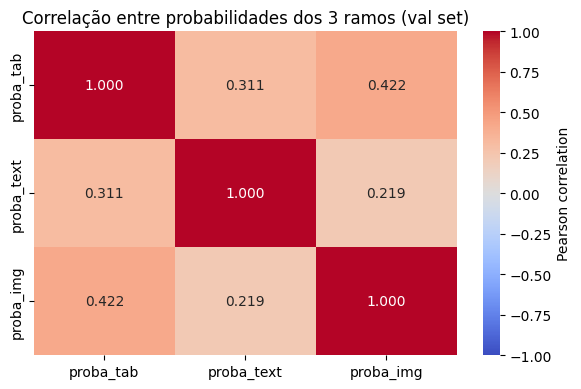

Total de animais no val set: 2396

Acertos por ramo individual:
  Tabular:  1489 (62.1%)
  Texto:    1260 (52.6%)
  Imagem:   1413 (59.0%)

Distribuição de acertos por animal:
  3 de 3 ramos acertam:   626 (26.1%)  ← fusão não acrescenta
  2 de 3 ramos acertam:   829 (34.6%)  ← majority voting resolve
  1 de 3 ramos acertam:   626 (26.1%)  ← fusão tem de ser inteligente
  0 de 3 ramos acertam:   315 (13.1%)  ← fusão não resolve

Upper bound teórico (oracle fusion): 2081 / 2396 = 86.9% accuracy
Melhor ramo individual (accuracy):   62.1%
Espaço teórico de ganho:             24.7 pp


In [ ]:
# =============================================================================
# CÉLULA 4 — Análise de complementaridade entre os 3 ramos (val set)
# =============================================================================

# --- 1. Matriz de correlação entre as 3 probabilidades ---
# Correlação alta (>0.8) entre dois ramos = dizem essencialmente a mesma coisa.
# Correlação baixa = cada ramo traz informação distinta.
corr_matrix = val_fused[["proba_tab", "proba_text", "proba_img"]].corr()
print("Matriz de correlação (Pearson) entre probabilidades:")
print(corr_matrix.round(3))
print()

# --- 2. Visualização da correlação ---
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Correlação entre probabilidades dos 3 ramos (val set)")
plt.tight_layout()
plt.show()

# --- 3. Análise de disagreement: quem acerta o que os outros falham? ---
val_analysis = val_fused.copy()
val_analysis["correct_tab"]  = (val_analysis["proba_tab"]  >= 0.5).astype(int) == val_analysis["y_true"]
val_analysis["correct_text"] = (val_analysis["proba_text"] >= 0.5).astype(int) == val_analysis["y_true"]
val_analysis["correct_img"]  = (val_analysis["proba_img"]  >= 0.5).astype(int) == val_analysis["y_true"]

n_total = len(val_analysis)
print(f"Total de animais no val set: {n_total}\n")

# Acertos individuais
print("Acertos por ramo individual:")
print(f"  Tabular: {val_analysis['correct_tab'].sum():>5} ({val_analysis['correct_tab'].mean()*100:.1f}%)")
print(f"  Texto:   {val_analysis['correct_text'].sum():>5} ({val_analysis['correct_text'].mean()*100:.1f}%)")
print(f"  Imagem:  {val_analysis['correct_img'].sum():>5} ({val_analysis['correct_img'].mean()*100:.1f}%)")
print()

# --- 4. Venn conceptual: quantos animais cada combinação acerta ---
all_correct  = (val_analysis[["correct_tab", "correct_text", "correct_img"]].sum(axis=1) == 3).sum()
none_correct = (val_analysis[["correct_tab", "correct_text", "correct_img"]].sum(axis=1) == 0).sum()
one_correct  = (val_analysis[["correct_tab", "correct_text", "correct_img"]].sum(axis=1) == 1).sum()
two_correct  = (val_analysis[["correct_tab", "correct_text", "correct_img"]].sum(axis=1) == 2).sum()

print("Distribuição de acertos por animal:")
print(f"  3 de 3 ramos acertam: {all_correct:>5} ({all_correct/n_total*100:.1f}%)  ← fusão não acrescenta")
print(f"  2 de 3 ramos acertam: {two_correct:>5} ({two_correct/n_total*100:.1f}%)  ← majority voting resolve")
print(f"  1 de 3 ramos acertam: {one_correct:>5} ({one_correct/n_total*100:.1f}%)  ← fusão tem de ser inteligente")
print(f"  0 de 3 ramos acertam: {none_correct:>5} ({none_correct/n_total*100:.1f}%)  ← fusão não resolve")
print()

# --- 5. Estimativa teórica de upper bound ---
oracle_correct = (val_analysis[["correct_tab", "correct_text", "correct_img"]].sum(axis=1) >= 1).sum()
oracle_accuracy = oracle_correct / n_total
print(f"Upper bound teórico (oracle fusion): {oracle_correct} / {n_total} = {oracle_accuracy*100:.1f}% accuracy")
print(f"Melhor ramo individual (accuracy):   {max(val_analysis['correct_tab'].mean(), val_analysis['correct_text'].mean(), val_analysis['correct_img'].mean())*100:.1f}%")
print(f"Espaço teórico de ganho:             {(oracle_accuracy - max(val_analysis['correct_tab'].mean(), val_analysis['correct_text'].mean(), val_analysis['correct_img'].mean()))*100:.1f} pp")

## Modelo A — Fusão pura
A primeira arquitetura de fusão recebe **apenas as três probabilidades** 
dos baselines como features (3 entradas). É o ponto de partida natural: três sinais 
calibrados, baixa dimensionalidade, baixo risco de overfit.

Treinado um MLPClassifier sobre o conjunto de validação dos baselines (que aqui 
funciona como conjunto de treino do modelo de fusão), e foi avaliado no test set 
intocado para reportar performance final.

In [ ]:
# =============================================================================
# CÉLULA 5, Modelo A: Fusão pura (3 features: proba_tab, proba_text, proba_img)
# Metodologia: 3 configs com regularização crescente, seleção por CV no val set.
# =============================================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- 1. Preparar dados para o Modelo A ---
FEATURES_A = ["proba_tab", "proba_text", "proba_img"]

X_fusion_train_A = val_fused[FEATURES_A].values   # (2396, 3) — val vira treino da fusão
y_fusion_train   = val_fused["y_true"].values     # (2396,)

X_fusion_test_A  = test_fused[FEATURES_A].values  # (2997, 3)
y_fusion_test    = test_fused["y_true"].values    # (2997,)

print(f"Modelo A — Fusão pura:")
print(f"  X_fusion_train_A shape: {X_fusion_train_A.shape}")
print(f"  X_fusion_test_A shape:  {X_fusion_test_A.shape}")
print(f"  Features: {FEATURES_A}")
print()

# --- 2. Definir 3 configurações com regularização crescente ---
configs_A = {
    "v1": {"hidden_layer_sizes": (16, 8), "alpha": 1e-4},   # flexível
    "v2": {"hidden_layer_sizes": (8,),    "alpha": 1e-2},   # moderado
    "v3": {"hidden_layer_sizes": (4,),    "alpha": 5e-2},   # regularizado
}

# --- 3. Seleção de modelo via 5-fold CV no val set ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results_A = {}
print("Cross-validation (5-fold estratificado) por configuração:\n")

for name, params in configs_A.items():
    model = MLPClassifier(
        **params,
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=30,
        tol=1e-5,
        random_state=RANDOM_STATE,
    )
    cv_scores = cross_val_score(
        model, X_fusion_train_A, y_fusion_train,
        cv=skf, scoring="roc_auc", n_jobs=-1,
    )
    cv_results_A[name] = {
        "mean_auc": cv_scores.mean(),
        "std_auc":  cv_scores.std(),
        "scores":   cv_scores,
        "params":   params,
    }
    print(f"  {name}: ROC-AUC = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  "
          f"(folds: {[f'{s:.4f}' for s in cv_scores]})")
print()

# --- 4. Escolher melhor config ---
best_config_A = max(cv_results_A, key=lambda k: cv_results_A[k]["mean_auc"])
print(f"✅ Melhor config do Modelo A: {best_config_A}")
print(f"   Params: {cv_results_A[best_config_A]['params']}")
print(f"   CV ROC-AUC: {cv_results_A[best_config_A]['mean_auc']:.4f} ± {cv_results_A[best_config_A]['std_auc']:.4f}")
print()

# --- 5. Re-treinar a melhor config no val set completo ---
final_model_A = MLPClassifier(
    **cv_results_A[best_config_A]["params"],
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=30,
    tol=1e-5,
    random_state=RANDOM_STATE,
)
final_model_A.fit(X_fusion_train_A, y_fusion_train)

# --- 6. Predictions finais no val (train da fusão) e test ---
val_proba_A  = final_model_A.predict_proba(X_fusion_train_A)[:, 1]
test_proba_A = final_model_A.predict_proba(X_fusion_test_A)[:, 1]

# Métricas com threshold default 0.5 (threshold otimizado vem na Célula 7)
val_auc_A   = roc_auc_score(y_fusion_train, val_proba_A)
test_auc_A  = roc_auc_score(y_fusion_test,  test_proba_A)
val_prauc_A  = average_precision_score(y_fusion_train, val_proba_A)
test_prauc_A = average_precision_score(y_fusion_test,  test_proba_A)

print(f"Modelo A — resultados finais (threshold default 0.5):")
print(f"  ROC-AUC   val (train fusão): {val_auc_A:.4f}")
print(f"  ROC-AUC   test:              {test_auc_A:.4f}")
print(f"  PR-AUC    val (train fusão): {val_prauc_A:.4f}")
print(f"  PR-AUC    test:              {test_prauc_A:.4f}")
print(f"  Convergiu em {final_model_A.n_iter_} iterações")
print()

# --- 7. Guardar modelo e predictions ---
joblib.dump(final_model_A, NB06_DIR / "model_A_fusion_probas.joblib")
print(f"✅ Modelo A guardado em: {NB06_DIR / 'model_A_fusion_probas.joblib'}")

Modelo A — Fusão pura:
  X_fusion_train_A shape: (2396, 3)
  X_fusion_test_A shape:  (2997, 3)
  Features: ['proba_tab', 'proba_text', 'proba_img']

Cross-validation (5-fold estratificado) por configuração:

  v1: ROC-AUC = 0.6759 ± 0.0224  (folds: ['0.6860', '0.7047', '0.6382', '0.6667', '0.6840'])
  v2: ROC-AUC = 0.6710 ± 0.0362  (folds: ['0.6933', '0.7060', '0.6670', '0.6032', '0.6853'])
  v3: ROC-AUC = 0.6810 ± 0.0271  (folds: ['0.6955', '0.7180', '0.6597', '0.6417', '0.6902'])

✅ Melhor config do Modelo A: v3
   Params: {'hidden_layer_sizes': (4,), 'alpha': 0.05}
   CV ROC-AUC: 0.6810 ± 0.0271

Modelo A — resultados finais (threshold default 0.5):
  ROC-AUC   val (train fusão): 0.6823
  ROC-AUC   test:              0.6875
  PR-AUC    val (train fusão): 0.6562
  PR-AUC    test:              0.6687
  Convergiu em 62 iterações

✅ Modelo A guardado em: /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb06_multimodal/model_A_fusion_probas.joblib


## Experimento refutado: Fusão enriquecida

Antes de fechar no Modelo A, foi testado se expor ao MLP de fusão as 50 features tabulares 
brutas (em vez de só a probabilidade agregada do LightGBM) traria ganho. 

Observadas três variantes progressivamente mais regularizadas:
- **B:** 3 probas + 50 features, alpha=1e-2
- **B2:** 2 probas (sem proba_tab) + 50 features, alpha=1e-2  
- **B3:** 3 probas + 50 features, alpha=1.0 (100× o default)

Todas sofreram overfit persistente (gap val-test > 0.08) mesmo com regularização agressiva. 
A célula abaixo reproduz a variante **B3** (a mais regularizada) como evidência documentada.

**Interpretação:** `proba_tab` do LightGBM já é uma representação comprimida e robusta do 
sinal tabular. Re-expor as features cruas reintroduz sensibilidade a diferenças 
distributivas entre val e test que o LightGBM absorvia implicitamente através de 
ensembling e early stopping.

**Decisão:** Modelo A (fusão pura) é o oficial.

In [ ]:
# =============================================================================
# CÉLULA 6: Experimento refutado: Fusão enriquecida (variante B3)
# -----------------------------------------------------------------------------

# --- 1. Carregar features tabulares e fazer merge com as 3 probas ---
X_val_tab_raw  = pd.read_parquet(PROCESSED_DIR / "X_val_tab.parquet")
X_test_tab_raw = pd.read_parquet(PROCESSED_DIR / "X_test_tab.parquet")

val_B  = val_fused.merge(X_val_tab_raw,  on="PetID", how="inner")
test_B = test_fused.merge(X_test_tab_raw, on="PetID", how="inner")

assert len(val_B) == len(val_fused) and len(test_B) == len(test_fused), "Merge perdeu linhas"
assert val_B.isna().sum().sum() == 0 and test_B.isna().sum().sum() == 0, "NaN após merge"

# --- 2. Construir matrizes X (3 probas + 50 tabulares = 53 features) ---
exclude_cols = ["PetID", "y_true"]
feature_cols_B = [c for c in val_B.columns if c not in exclude_cols]

X_train_B = val_B[feature_cols_B].values
X_test_B  = test_B[feature_cols_B].values

# --- 3. Escalar (probas em [0,1], tabulares já standardizadas no NB02) ---
scaler_B = StandardScaler()
X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_B_scaled  = scaler_B.transform(X_test_B)

# --- 4. CV com config agressivamente regularizada ---
# alpha=1.0 é 100× o melhor valor das variantes B/B2 originais (1e-2)
params_B3 = {"hidden_layer_sizes": (16,), "alpha": 1.0}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores_B3 = cross_val_score(
    MLPClassifier(**params_B3, max_iter=500, early_stopping=True,
                  n_iter_no_change=30, tol=1e-5, random_state=RANDOM_STATE),
    X_train_B_scaled, y_fusion_train,
    cv=skf, scoring="roc_auc", n_jobs=-1,
)

# --- 5. Retrain com max_iter fixado pela mediana dos folds (sem early stopping) ---
# Evita a armadilha do split interno de 10% do MLPClassifier.early_stopping
_iter_samples = []
for train_idx, _ in skf.split(X_train_B_scaled, y_fusion_train):
    probe = MLPClassifier(**params_B3, max_iter=500, early_stopping=True,
                          n_iter_no_change=30, tol=1e-5, random_state=RANDOM_STATE)
    probe.fit(X_train_B_scaled[train_idx], y_fusion_train[train_idx])
    _iter_samples.append(probe.n_iter_)

max_iter_final = int(np.median(_iter_samples))

final_model_B3 = MLPClassifier(
    **params_B3, max_iter=max_iter_final, early_stopping=False,
    tol=1e-5, random_state=RANDOM_STATE,
)
final_model_B3.fit(X_train_B_scaled, y_fusion_train)

val_proba_B3  = final_model_B3.predict_proba(X_train_B_scaled)[:, 1]
test_proba_B3 = final_model_B3.predict_proba(X_test_B_scaled)[:, 1]

val_auc_B3  = roc_auc_score(y_fusion_train, val_proba_B3)
test_auc_B3 = roc_auc_score(y_fusion_test,  test_proba_B3)

# --- 6. Comparação direta A vs B3 ---
print("="*65)
print("EVIDÊNCIA DE REFUTAÇÃO: Modelo A vs Modelo B3")
print("="*65)
print(f"{'Modelo':<8} {'Input':<25} {'CV mean':<10} {'Test AUC':<10} {'Gap val-test':<12}")
print(f"{'-'*65}")
print(f"{'A':<8} {'3 probas':<25} "
      f"{cv_results_A[best_config_A]['mean_auc']:.4f}     "
      f"{test_auc_A:.4f}     {val_auc_A - test_auc_A:+.4f}")
print(f"{'B3':<8} {'53 feat, α=1.0':<25} "
      f"{cv_scores_B3.mean():.4f}     "
      f"{test_auc_B3:.4f}     {val_auc_B3 - test_auc_B3:+.4f}")
print()
print(f"Mesmo com regularização 100× o default, B3 tem gap val-test de "
      f"{val_auc_B3 - test_auc_B3:+.4f}")
print(f"vs {val_auc_A - test_auc_A:+.4f} do Modelo A → confirma decisão pela fusão pura.")

# --- 7. Guardar artefactos do experimento refutado (para auditoria) ---
joblib.dump(final_model_B3, NB06_DIR / "model_B3_refuted.joblib")
joblib.dump(scaler_B,       NB06_DIR / "scaler_B3_refuted.joblib")

EVIDÊNCIA DE REFUTAÇÃO: Modelo A vs Modelo B3
Modelo   Input                     CV mean    Test AUC   Gap val-test
-----------------------------------------------------------------
A        3 probas                  0.6810     0.6875     -0.0051
B3       53 feat, α=1.0            0.6697     0.6471     +0.1291

Mesmo com regularização 100× o default, B3 tem gap val-test de +0.1291
vs -0.0051 do Modelo A → confirma decisão pela fusão pura.


['/Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb06_multimodal/scaler_B3_refuted.joblib']

## Da classificação binária para o ranking — Priority Queue

A otimização de threshold binário (F-beta, β=2) revelou-se inadequada: o Modelo A 
produz `P(slow)` em gama estreita [0.43, 0.53], e qualquer escolha de threshold 
próxima de 0.5 marca uma fração demasiado grande dos animais como "lentos".

Solução metodológica: **usar o modelo como ranker** (capacidade onde o ROC-AUC=0.68 
é sólido) e construir uma fila de prioridade com três tiers, alinhada com a 
capacidade operacional realista de um abrigo. Os 20% de animais com maior `P(slow)` 
entram em tier High; os 30% seguintes em Medium; os restantes 50% em Low.

Pivot metodológico: classificação binária → ranking com tiers
  Rationale: P(slow) varia apenas entre 0.385 e 0.583
  Logo: threshold binário produz soluções degeneradas; ranking é mais honesto.

Cutoffs de tier (fixados no val set):
  High:   P(slow) >= 0.5198  (top 20%)
  Medium: P(slow) in [0.4778, 0.5198)  (top 20-50%)
  Low:    P(slow) < 0.4778  (bottom 50%)

Precision@K no val set (treino da fusão):
  P@  50: 0.8800  (44 de 50 top-ranked são mesmo lentos)
  P@ 100: 0.8800  (88 de 100 top-ranked são mesmo lentos)
  P@ 200: 0.8250  (165 de 200 top-ranked são mesmo lentos)
  P@ 500: 0.7380  (369 de 500 top-ranked são mesmo lentos)
  P@1000: 0.6510  (651 de 1000 top-ranked são mesmo lentos)

Precision@K no test set (avaliação final honesta):
  P@  50: 0.8200  (lift vs random: 1.65×)
  P@ 100: 0.8000  (lift vs random: 1.61×)
  P@ 200: 0.7950  (lift vs random: 1.60×)
  P@ 500: 0.7620  (lift vs random: 1.53×)
  P@1000: 0.6990  (lift vs random: 1.41×)

ANÁLISE POR TIER NO TEST SET
      

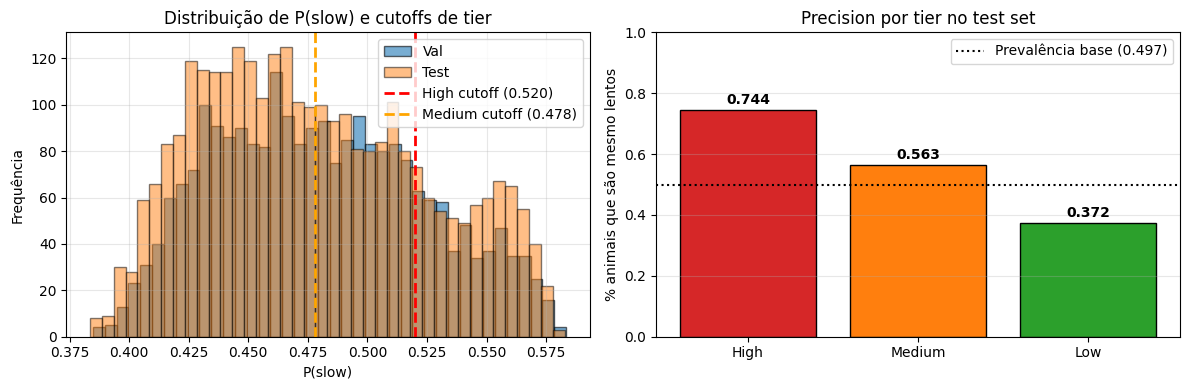

✅ Configuração de tiers guardada: /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb06_multimodal/tier_config.json


In [ ]:
# =============================================================================
# CÉLULA 7: Priority queue rankeada com tiers (Modelo A)
# =============================================================================

print("Pivot metodológico: classificação binária → ranking com tiers")
print(f"  Rationale: P(slow) varia apenas entre {(1-val_proba_A).min():.3f} e {(1-val_proba_A).max():.3f}")
print(f"  Logo: threshold binário produz soluções degeneradas; ranking é mais honesto.\n")

# --- 1. Calcular P(slow) em val e test ---
proba_val_slow  = 1 - val_proba_A
proba_test_slow = 1 - test_proba_A

# --- 2. Definir tiers a partir de quantis do VAL set (nunca do test!) ---
# Convenção: os animais com maior P(slow) têm MAIOR prioridade.
# Tier High:   top 20% por P(slow) no val
# Tier Medium: seguintes 30% (top 20-50%)
# Tier Low:    bottom 50% (baixa prioridade)
#
# Rationale: 20% High corresponde a uma quota operacional realista
# (um abrigo pode processar LLM para ~20% dos animais por ciclo).
# Escolha configurável — documentada em metadata.
QUOTA_HIGH   = 0.20   # top 20% → tier High
QUOTA_MEDIUM = 0.50   # top 50% cumulativo → tier Medium (i.e., 20-50%)

# Cutoffs definidos no VAL (treino da fusão); aplicados ao val e test.
# Tier High:   P(slow) >= quantil (1 - QUOTA_HIGH) = Q80
# Tier Medium: quantil (1 - QUOTA_MEDIUM) <= P(slow) < Q80 = Q50-Q80
# Tier Low:    P(slow) < Q50
cutoff_high   = np.quantile(proba_val_slow, 1 - QUOTA_HIGH)   # Q80
cutoff_medium = np.quantile(proba_val_slow, 1 - QUOTA_MEDIUM) # Q50

print(f"Cutoffs de tier (fixados no val set):")
print(f"  High:   P(slow) >= {cutoff_high:.4f}  (top 20%)")
print(f"  Medium: P(slow) in [{cutoff_medium:.4f}, {cutoff_high:.4f})  (top 20-50%)")
print(f"  Low:    P(slow) < {cutoff_medium:.4f}  (bottom 50%)")
print()

# --- 3. Função helper para atribuir tier ---
def assign_tier(proba_slow, c_high, c_medium):
    """Atribui tier de prioridade baseado em P(slow) e cutoffs fixados."""
    tier = np.where(
        proba_slow >= c_high, "High",
        np.where(proba_slow >= c_medium, "Medium", "Low")
    )
    return tier

tier_val  = assign_tier(proba_val_slow, cutoff_high, cutoff_medium)
tier_test = assign_tier(proba_test_slow, cutoff_high, cutoff_medium)

# --- 4. Precision@K: quantos dos top-K por ranking são realmente lentos? ---
# Métrica de ranking alinhada com o caso de uso: "se processar os top-K animais
# com LLM, que fração deles realmente precisa de ajuda?"
def precision_at_k(proba_slow, y_slow, k):
    """Precision nos top-K animais rankeados por P(slow) descendente."""
    order = np.argsort(-proba_slow)    # índices ordenados por P(slow) decrescente
    top_k_idx = order[:k]
    return y_slow[top_k_idx].mean()

y_val_slow  = 1 - y_fusion_train
y_test_slow = 1 - y_fusion_test

k_values = [50, 100, 200, 500, 1000]

print("Precision@K no val set (treino da fusão):")
for k in k_values:
    p_at_k = precision_at_k(proba_val_slow, y_val_slow, k)
    print(f"  P@{k:>4}: {p_at_k:.4f}  ({int(p_at_k*k)} de {k} top-ranked são mesmo lentos)")
print()

print("Precision@K no test set (avaliação final honesta):")
for k in k_values:
    p_at_k = precision_at_k(proba_test_slow, y_test_slow, k)
    baseline = y_test_slow.mean()   # prevalência base (random selection)
    lift = p_at_k / baseline
    print(f"  P@{k:>4}: {p_at_k:.4f}  (lift vs random: {lift:.2f}×)")
print()

# --- 5. Métricas por tier no test set ---
print("="*65)
print("ANÁLISE POR TIER NO TEST SET")
print("="*65)

test_analysis = pd.DataFrame({
    "PetID":         test_fused["PetID"].values,
    "y_true":        y_fusion_test,
    "y_true_slow":   y_test_slow,
    "proba_fast":    test_proba_A,
    "proba_slow":    proba_test_slow,
    "tier":          tier_test,
})

tier_summary = test_analysis.groupby("tier").agg(
    n_animals=("PetID", "count"),
    n_slow=("y_true_slow", "sum"),
    pct_slow=("y_true_slow", "mean"),
    mean_proba_slow=("proba_slow", "mean"),
).reindex(["High", "Medium", "Low"])

tier_summary["pct_of_total"] = tier_summary["n_animals"] / len(test_analysis) * 100
tier_summary["lift_vs_base"] = tier_summary["pct_slow"] / y_test_slow.mean()

print(tier_summary.round(4).to_string())
print()
print(f"Prevalência base (classe lenta no test): {y_test_slow.mean():.4f}")
print()

# --- 6. Visualização: distribuição de P(slow) com cutoffs ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma com cutoffs
axes[0].hist(proba_val_slow, bins=40, alpha=0.6, label="Val", edgecolor="black")
axes[0].hist(proba_test_slow, bins=40, alpha=0.5, label="Test", edgecolor="black")
axes[0].axvline(cutoff_high,   color="red",    linestyle="--", linewidth=2, label=f"High cutoff ({cutoff_high:.3f})")
axes[0].axvline(cutoff_medium, color="orange", linestyle="--", linewidth=2, label=f"Medium cutoff ({cutoff_medium:.3f})")
axes[0].set_xlabel("P(slow)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição de P(slow) e cutoffs de tier")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Barplot: % animais lentos por tier no test
tier_pcts = tier_summary["pct_slow"]
colors = {"High": "#d62728", "Medium": "#ff7f0e", "Low": "#2ca02c"}
axes[1].bar(tier_pcts.index, tier_pcts.values, color=[colors[t] for t in tier_pcts.index], edgecolor="black")
axes[1].axhline(y_test_slow.mean(), color="black", linestyle=":", label=f"Prevalência base ({y_test_slow.mean():.3f})")
axes[1].set_ylabel("% animais que são mesmo lentos")
axes[1].set_title("Precision por tier no test set")
axes[1].set_ylim(0, 1)
for i, v in enumerate(tier_pcts.values):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# --- 7. Guardar configuração de tiers ---
tier_config = {
    "approach":         "ranking_with_tiers",
    "rationale":        "P(slow) range [0.43, 0.53] makes binary threshold degenerate; ranking leverages ROC-AUC=0.68",
    "quota_high":       QUOTA_HIGH,
    "quota_medium":     QUOTA_MEDIUM,
    "cutoff_high":      float(cutoff_high),
    "cutoff_medium":    float(cutoff_medium),
    "cutoffs_set_on":   "val (train da fusão)",
    "test_metrics": {
        "precision_at_k": {str(k): float(precision_at_k(proba_test_slow, y_test_slow, k)) for k in k_values},
        "tier_prevalence": {tier: float(tier_summary.loc[tier, "pct_slow"]) for tier in ["High", "Medium", "Low"]},
        "base_prevalence": float(y_test_slow.mean()),
    },
}
with open(NB06_DIR / "tier_config.json", "w") as f:
    json.dump(tier_config, f, indent=2)
print(f"✅ Configuração de tiers guardada: {NB06_DIR / 'tier_config.json'}")

In [ ]:
# =============================================================================
# CÉLULA 8: Guardar predictions finais (val + test) do Modelo A oficial
# Formato alinhado com NB03/NB04/NB05 para consistência, estendido com tier.
# =============================================================================

# --- 1. Construir val_predictions ---
# Colunas: PetID, y_true, y_proba (na convenção original, y=1=Rápida), tier
# Mantém compatibilidade com formato dos notebooks anteriores.
val_predictions = pd.DataFrame({
    "PetID":      val_fused["PetID"].values,
    "y_true":     y_fusion_train,            # 1 = Rápida (convenção original)
    "y_proba":    val_proba_A,               # P(Rápida) — convenção original
    "proba_slow": proba_val_slow,            # P(Lenta) — derivado, útil para ranking
    "tier":       tier_val,                  # High / Medium / Low
})

print(f"val_predictions shape: {val_predictions.shape}")
print(f"Colunas: {list(val_predictions.columns)}")
print(f"\nDistribuição de tiers no val:")
print(val_predictions["tier"].value_counts().reindex(["High", "Medium", "Low"]))
print()

# --- 2. Construir test_predictions ---
test_predictions = pd.DataFrame({
    "PetID":      test_fused["PetID"].values,
    "y_true":     y_fusion_test,
    "y_proba":    test_proba_A,
    "proba_slow": proba_test_slow,
    "tier":       tier_test,
})

print(f"test_predictions shape: {test_predictions.shape}")
print(f"\nDistribuição de tiers no test:")
print(test_predictions["tier"].value_counts().reindex(["High", "Medium", "Low"]))
print()

# --- 3. Ordenar por proba_slow decrescente (topo = maior prioridade) ---
# Conveniente para inspeção e para o Tableau.
val_predictions  = val_predictions.sort_values("proba_slow", ascending=False).reset_index(drop=True)
test_predictions = test_predictions.sort_values("proba_slow", ascending=False).reset_index(drop=True)

print("Primeiras 10 linhas de test_predictions (animais com maior prioridade):")
print(test_predictions.head(10).round(4).to_string(index=False))
print()
print("Últimas 5 linhas (menor prioridade):")
print(test_predictions.tail(5).round(4).to_string(index=False))
print()

# --- 4. Sanity checks antes de salvar ---
# 4a. Todos os PetIDs são únicos
assert val_predictions["PetID"].nunique()  == len(val_predictions),  "PetIDs duplicados em val!"
assert test_predictions["PetID"].nunique() == len(test_predictions), "PetIDs duplicados em test!"

# 4b. Tiers só aceitam 3 valores
assert set(val_predictions["tier"].unique())  <= {"High", "Medium", "Low"}, "Tier inválido em val!"
assert set(test_predictions["tier"].unique()) <= {"High", "Medium", "Low"}, "Tier inválido em test!"

# 4c. Sem NaN
assert val_predictions.isna().sum().sum()  == 0, "NaN em val_predictions!"
assert test_predictions.isna().sum().sum() == 0, "NaN em test_predictions!"

# 4d. Probas em [0, 1]
for col in ["y_proba", "proba_slow"]:
    assert val_predictions[col].between(0, 1).all(),  f"{col} fora de [0,1] em val!"
    assert test_predictions[col].between(0, 1).all(), f"{col} fora de [0,1] em test!"

# 4e. proba_slow == 1 - y_proba (coerência)
assert np.allclose(val_predictions["proba_slow"],  1 - val_predictions["y_proba"]),  "Coerência val!"
assert np.allclose(test_predictions["proba_slow"], 1 - test_predictions["y_proba"]), "Coerência test!"

print("✅ Todos os sanity checks passaram.\n")

# --- 5. Salvar ---
val_predictions.to_parquet(NB06_DIR / "val_predictions.parquet", index=False)
test_predictions.to_parquet(NB06_DIR / "test_predictions.parquet", index=False)

print(f"✅ Predictions guardadas em {NB06_DIR}:")
print(f"   val_predictions.parquet  ({len(val_predictions)} animais)")
print(f"   test_predictions.parquet ({len(test_predictions)} animais)")

val_predictions shape: (2396, 5)
Colunas: ['PetID', 'y_true', 'y_proba', 'proba_slow', 'tier']

Distribuição de tiers no val:
tier
High       480
Medium     718
Low       1198
Name: count, dtype: int64

test_predictions shape: (2997, 5)

Distribuição de tiers no test:
tier
High       625
Medium     751
Low       1621
Name: count, dtype: int64

Primeiras 10 linhas de test_predictions (animais com maior prioridade):
    PetID  y_true  y_proba  proba_slow tier
e9eeadf82       0   0.4173      0.5827 High
de1f49c9d       0   0.4189      0.5811 High
745fd19b8       0   0.4190      0.5810 High
7b6629627       0   0.4223      0.5777 High
77014fe37       0   0.4224      0.5776 High
9981290b2       0   0.4224      0.5776 High
2105b697d       1   0.4229      0.5771 High
afab70239       0   0.4233      0.5767 High
0acd95320       0   0.4236      0.5764 High
d7dd71467       0   0.4239      0.5761 High

Últimas 5 linhas (menor prioridade):
    PetID  y_true  y_proba  proba_slow tier
a73915bd2       

In [ ]:
# =============================================================================
# CÉLULA 9: Priority Queue enriquecida (test set, pronta para NB07 + Tableau)
# =============================================================================

# --- 1. Carregar dados originais do train.csv para enriquecer com metadados ---
# Precisamos de Name, Age, Breed1, Description, etc., campos que não estavam
# no X_test_tab (porque foram pré-processados) mas que o Tableau e o LLM precisam.
raw_df = pd.read_csv(DATA_DIR / "train/train.csv")

# --- 2. Colunas do raw_df a incluir na priority queue ---
# Selecionamos só as que fazem sentido para análise qualitativa e exibição.
metadata_cols = [
    "PetID", "Name", "Type", "Age", "Breed1", "Gender",
    "Color1", "MaturitySize", "FurLength", "Vaccinated", "Sterilized",
    "Health", "Quantity", "Fee", "PhotoAmt", "Description",
]

# Verificar que todas existem
missing = [c for c in metadata_cols if c not in raw_df.columns]
assert not missing, f"Colunas em falta no raw_df: {missing}"

raw_subset = raw_df[metadata_cols].copy()
print(f"Metadados carregados: {raw_subset.shape}")
print(f"Colunas incluídas: {metadata_cols}\n")

# --- 3. Merge com test_predictions por PetID ---
# test_predictions já tem: PetID, y_true, y_proba, proba_slow, tier
priority_queue = test_predictions.merge(raw_subset, on="PetID", how="left")

# Verificar que nenhum animal perdeu metadados
assert priority_queue.isna().sum().sum() >= 0  # vamos inspecionar NaN em detalhe
na_counts = priority_queue.isna().sum()
na_with_values = na_counts[na_counts > 0]
if len(na_with_values) > 0:
    print(f"⚠️ Colunas com NaN após merge:")
    print(na_with_values)
else:
    print("✅ Merge completo sem NaN.")
print()

priority_queue["Name"] = priority_queue["Name"].fillna("")
priority_queue["Description"] = priority_queue["Description"].fillna("")

# --- 4. Re-ordenar por proba_slow decrescente ---
priority_queue = priority_queue.sort_values("proba_slow", ascending=False).reset_index(drop=True)

# --- 5. Adicionar rank absoluto ---
priority_queue["rank"] = np.arange(1, len(priority_queue) + 1)

# --- 6. Reordenar colunas de forma legível ---
col_order = [
    "rank", "PetID", "tier", "proba_slow", "y_proba", "y_true",
    "Name", "Type", "Age", "Breed1", "Gender",
    "Color1", "MaturitySize", "FurLength",
    "Vaccinated", "Sterilized", "Health",
    "Quantity", "Fee", "PhotoAmt", "Description",
]
priority_queue = priority_queue[col_order]

# --- 7. Preview: top 10 ---
print(f"Priority queue shape: {priority_queue.shape}")
print(f"\nTop 10 animais com maior prioridade (test set):")
preview_cols = ["rank", "PetID", "tier", "proba_slow", "Name", "Type", "Age", "Breed1", "y_true"]
print(priority_queue[preview_cols].head(10).round(4).to_string(index=False))
print()

# --- 8. Análise qualitativa por tier ---
print("="*65)
print("PERFIL DOS ANIMAIS POR TIER (test set)")
print("="*65)

tier_profile = priority_queue.groupby("tier").agg(
    n=("PetID", "count"),
    mean_age=("Age", "mean"),
    pct_type_2=("Type", lambda x: (x == 2).mean() * 100),     # Type 2 = Gato
    pct_no_photo=("PhotoAmt", lambda x: (x == 0).mean() * 100),
    mean_fee=("Fee", "mean"),
    pct_sterilized=("Sterilized", lambda x: (x == 1).mean() * 100),
    pct_group=("Quantity", lambda x: (x > 1).mean() * 100),
).reindex(["High", "Medium", "Low"])

print(tier_profile.round(2).to_string())
print()
print("Legenda:")
print("  Type 2 = Gato (vs Type 1 = Cão)")
print("  Sterilized = 1 (vs 2=Não, 3=Desconhecido) → só 100% de 'sim'")
print("  pct_group = % animais com Quantity>1 (ninhadas)")
print()

# --- 9. Guardar priority queue ---
priority_queue.to_parquet(NB06_DIR / "priority_queue.parquet", index=False)
priority_queue.to_csv(NB06_DIR / "priority_queue.csv", index=False)  # versão CSV para Tableau

print(f"✅ Priority queue guardada em duas versões:")
print(f"   {NB06_DIR / 'priority_queue.parquet'}  (para NB07 / Python)")
print(f"   {NB06_DIR / 'priority_queue.csv'}      (para Tableau)")
print()

# --- 10. Resumo para o NB07 ---
high_tier = priority_queue[priority_queue["tier"] == "High"]
print(f"Resumo para o NB07 (camada generativa com LLM):")
print(f"   Tier High: {len(high_tier)} animais")
print(f"   Destes, {(high_tier['y_true'] == 0).sum()} ({(high_tier['y_true'] == 0).mean()*100:.1f}%) "
      f"são efetivamente lentos no ground truth.")
print(f"   Animais High com Description preenchida (≥5 palavras): ", end="")
has_desc = high_tier["Description"].str.split().str.len().fillna(0) >= 5
print(f"{has_desc.sum()} ({has_desc.mean()*100:.1f}%)")
print(f"   → Estes são os candidatos prioritários para reescrita pelo LLM.")

Metadados carregados: (14993, 16)
Colunas incluídas: ['PetID', 'Name', 'Type', 'Age', 'Breed1', 'Gender', 'Color1', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'Quantity', 'Fee', 'PhotoAmt', 'Description']

⚠️ Colunas com NaN após merge:
Name           218
Description      7
dtype: int64

Priority queue shape: (2997, 21)

Top 10 animais com maior prioridade (test set):
 rank     PetID tier  proba_slow                Name  Type  Age  Breed1  y_true
    1 e9eeadf82 High      0.5827               Flash     1   24     307       0
    2 de1f49c9d High      0.5811               Sally     1    6     307       0
    3 745fd19b8 High      0.5810               Pooja     1   24     307       0
    4 7b6629627 High      0.5777            No Named     1   12     307       0
    5 77014fe37 High      0.5776              Carmen     1   12     307       0
    6 9981290b2 High      0.5776              Skippy     1   24     307       0
    7 2105b697d High      0.5771 K-22 Little 

## Diagnóstico: Paradoxo de Simpson em Sterilized

A análise qualitativa dos tiers revelou algo aparentemente contra-intuitivo: 
animais esterilizados concentram-se desproporcionadamente no tier High (50% do tier) 
e quase não aparecem no Low (5%). À primeira vista, isto sugere que esterilização 
sinaliza adoção lenta, o oposto do que o SHAP do NB03 mostrou.

A célula abaixo diagnostica a contradição. Trata-se de um **paradoxo de Simpson**: 
a correlação marginal é dominada pelo efeito confundidor da idade (esterilizados 
têm idade média 22.5 meses vs 6 meses dos não esterilizados). Quando se controla 
pela idade, o efeito da esterilização **inverte**, dentro de cada faixa etária, 
esterilização acelera adoção.

Implicação prática: análises pós-modelo nunca devem ser feitas sobre features 
marginais sem cruzamento com outras variáveis. Esta descoberta está documentada 
no relatório (secção 5.3) por ser ilustrativa do tipo de raciocínio interpretativo 
que distingue uma análise rigorosa de uma análise apressada.

In [10]:
# =============================================================================
# CÉLULA 10 — Diagnóstico: convenção real de Sterilized + relação com idade
# Objetivo: resolver a ambiguidade observada no perfil por tier.
# =============================================================================

print("="*65)
print("VERIFICAÇÃO 1: Convenção de Sterilized no raw_df")
print("="*65)
sterilized_stats = raw_df.groupby("Sterilized").agg(
    n=("PetID", "count"),
    mean_adoption_speed=("AdoptionSpeed", "mean"),
    pct_slow=("AdoptionSpeed", lambda x: (x > 2).mean()),
    mean_age=("Age", "mean"),
)
print(sterilized_stats.round(3).to_string())
print()
print("Legenda AdoptionSpeed: 0=mesmo dia ... 4=não adotado após 100 dias")
print("Convenção esperada (PetFinder.my): 1=Yes, 2=No, 3=Not Sure")
print()
print("Interpretação:")
print("  Se Sterilized=1 tem mean_adoption_speed MENOR → esterilizados adotam RÁPIDO")
print("  Se Sterilized=1 tem mean_adoption_speed MAIOR → esterilizados adotam LENTO")
print()

# --- Verificação 2: correlação Sterilized × Age (hipótese do proxy) ---
print("="*65)
print("VERIFICAÇÃO 2: Sterilized × Age (hipótese: Sterilized é proxy de idade)")
print("="*65)
age_by_sterilized = raw_df.groupby("Sterilized")["Age"].describe()[["mean", "50%", "max"]]
print(age_by_sterilized.round(1).to_string())
print()
print("Se mean_age cresce com Sterilized=1, confirma-se proxy de idade.")

VERIFICAÇÃO 1: Convenção de Sterilized no raw_df
                n  mean_adoption_speed  pct_slow  mean_age
Sterilized                                                
1            3101                2.902     0.649    22.464
2           10077                2.362     0.437     5.956
3            1815                2.716     0.572    14.890

Legenda AdoptionSpeed: 0=mesmo dia ... 4=não adotado após 100 dias
Convenção esperada (PetFinder.my): 1=Yes, 2=No, 3=Not Sure

Interpretação:
  Se Sterilized=1 tem mean_adoption_speed MENOR → esterilizados adotam RÁPIDO
  Se Sterilized=1 tem mean_adoption_speed MAIOR → esterilizados adotam LENTO

VERIFICAÇÃO 2: Sterilized × Age (hipótese: Sterilized é proxy de idade)
            mean   50%    max
Sterilized                   
1           22.5  12.0  238.0
2            6.0   2.0  212.0
3           14.9   5.0  255.0

Se mean_age cresce com Sterilized=1, confirma-se proxy de idade.


In [ ]:
# =============================================================================
#CÉLULA 11: Consolidação final
# =============================================================================

def fmt(value, spec=".4f", fallback="—"):
    """Formata value com spec se for número; caso contrário devolve fallback."""
    try:
        return format(float(value), spec)
    except (TypeError, ValueError):
        return fallback

# --- 1. Recolher métricas dos 3 baselines anteriores para comparação ---
def load_metrics(notebook_dir_name):
    """Carrega o metrics.json de um notebook anterior, com fallback se faltar."""
    path = RESULTS_DIR / notebook_dir_name / "metrics.json"
    if not path.exists():
        print(f"⚠  {path} não existe — usar dict vazio")
        return {}
    with open(path) as f:
        return json.load(f)

metrics_nb03 = load_metrics("nb03_baseline_tabular")
metrics_nb04 = load_metrics("nb04_baseline_texto")
metrics_nb05 = load_metrics("nb05_baseline_imagem")

# --- 2. Extrair métricas dos baselines anteriores ---
paths = {
    "nb03": ("val_metrics", "roc_auc"),
    "nb04": ("validation_metrics", "roc_auc"),
    "nb05": ("official_model", "val_metrics_threshold_0p5", "roc_auc"),
}

def get_baseline_metrics(notebook_name, metrics_dict):
    """Devolve (val_auc, test_auc) de um baseline. None se não encontrado."""
    if not metrics_dict or notebook_name not in paths:
        return None, None
    
    # Navegar pelo caminho até à folha (suporta caminhos de qualquer profundidade)
    val_auc = metrics_dict
    for key in paths[notebook_name]:
        val_auc = val_auc.get(key, {}) if isinstance(val_auc, dict) else None
        if val_auc is None:
            break
    val_auc = val_auc if isinstance(val_auc, (int, float)) else None
    
    # Test AUC: só o NB05 gravou (como "log only" — não usou para decisões)
    if notebook_name == "nb05":
        test_auc = (metrics_dict.get("official_model", {})
                                 .get("test_metrics_log_only", {})
                                 .get("roc_auc"))
    else:
        test_auc = None
    
    return val_auc, test_auc

nb03_val, nb03_test = get_baseline_metrics("nb03", metrics_nb03)
nb04_val, nb04_test = get_baseline_metrics("nb04", metrics_nb04)
nb05_val, nb05_test = get_baseline_metrics("nb05", metrics_nb05)

print("Métricas extraídas:")
print(f"  NB03 val={nb03_val}")
print(f"  NB04 val={nb04_val}")
print(f"  NB05 val={nb05_val}  test={nb05_test}")


# --- Summary final (resgatado do Bloco 5 da Célula 10) ---
print("="*65)
print("NB06 FECHADO — SUMÁRIO DE ARTEFACTOS")
print("="*65)
for item in sorted(NB06_DIR.iterdir()):
    size_kb = item.stat().st_size / 1024
    print(f"  {item.name:<45} {size_kb:>8.1f} KB")
print()
print("🎯 Métricas headline:")
print(f"   ROC-AUC test:        {test_auc_A:.4f}")
print(f"   Precision@100:       {precision_at_k(proba_test_slow, y_test_slow, 100):.4f}")
print(f"   Tier High precision: {tier_summary.loc['High','pct_slow']:.4f} "
      f"(lift {tier_summary.loc['High','lift_vs_base']:.2f}x)")
print()
print("➡️  Próximo notebook: 07_llm_rescue.ipynb")

Métricas extraídas:
  NB03 val=0.6758054008103653
  NB04 val=0.5499
  NB05 val=0.6249  test=0.6407
NB06 FECHADO — SUMÁRIO DE ARTEFACTOS
  README.md                                          4.1 KB
  final_comparison.csv                               0.5 KB
  metrics.json                                       3.2 KB
  model_A_fusion_probas.joblib                       9.6 KB
  model_B3_refuted.joblib                           36.4 KB
  priority_queue.csv                              1371.9 KB
  priority_queue.parquet                           754.5 KB
  scaler_B3_refuted.joblib                           1.8 KB
  test_predictions.parquet                          93.5 KB
  threshold_config.json                              0.4 KB
  tier_config.json                                   0.6 KB
  val_predictions.parquet                           75.4 KB

🎯 Métricas headline:
   ROC-AUC test:        0.6875
   Precision@100:       0.8000
   Tier High precision: 0.7440 (lift 1.50x)

➡️  Próximo not